In [1]:
# 02 - CLUSTERING

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# Reload our data from notebook 01
import os

data_path = "../data/ebm_nlp_2_00"

# Copy the load function here so we don't need notebook 01 open
def load_ebm_nlp_data(data_path, split="train", max_docs=500):
    pico_types = ["participants", "interventions", "outcomes"]
    ann_base = data_path + f"/annotations/aggregated/hierarchical_labels/participants/{split}"
    doc_ids = [f.replace(".AGGREGATED.ann", "") for f in os.listdir(ann_base)]
    doc_ids = doc_ids[:max_docs]
    print(f"Loading {len(doc_ids)} documents...")
    rows = []
    for doc_id in doc_ids:
        token_path = data_path + f"/documents/{doc_id}.tokens"
        if not os.path.exists(token_path):
            continue
        with open(token_path, "r") as f:
            tokens = f.read().strip().split("\n")
        all_labels = {}
        for pico in pico_types:
            ann_path = data_path + f"/annotations/aggregated/hierarchical_labels/{pico}/{split}/{doc_id}.AGGREGATED.ann"
            if os.path.exists(ann_path):
                with open(ann_path, "r") as f:
                    labels = [int(x) for x in f.read().strip().split("\n")]
                all_labels[pico] = labels
        current_sentence = []
        current_labels = {pico: [] for pico in pico_types}
        for i, token in enumerate(tokens):
            current_sentence.append(token)
            for pico in pico_types:
                if pico in all_labels and i < len(all_labels[pico]):
                    current_labels[pico].append(all_labels[pico][i])
                else:
                    current_labels[pico].append(0)
            if token in [".", "?", "!"]:
                if len(current_sentence) > 3:
                    sentence_text = " ".join(current_sentence)
                    pico_counts = {}
                    for pico in pico_types:
                        pico_counts[pico] = sum(1 for l in current_labels[pico] if l != 0)
                    dominant_pico = max(pico_counts, key=pico_counts.get)
                    max_count = pico_counts[dominant_pico]
                    if max_count == 0:
                        dominant_pico = "none"
                    rows.append({
                        "doc_id": doc_id,
                        "sentence": sentence_text,
                        "label": dominant_pico,
                        "participants_count": pico_counts["participants"],
                        "interventions_count": pico_counts["interventions"],
                        "outcomes_count": pico_counts["outcomes"]
                    })
                current_sentence = []
                current_labels = {pico: [] for pico in pico_types}
    df = pd.DataFrame(rows)
    print(f" Loaded {len(df)} sentences from {len(doc_ids)} documents")
    return df

# Load data
df = load_ebm_nlp_data(data_path)
print(df["label"].value_counts())

Loading 500 documents...
 Loaded 5590 sentences from 500 documents
label
outcomes         2195
interventions    1406
none             1220
participants      769
Name: count, dtype: int64


In [3]:
# STEP 1 - TF-IDF REPRESENTATION

print(" Converting sentences to TF-IDF vectors...")

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=3000,    # only keep top 3000 most important words
    stop_words="english", # remove common words like "the", "a", "is"
    ngram_range=(1, 2),   # use single words AND pairs of words
    min_df=5              # ignore words that appear in less than 5 sentences
)

# Convert sentences to numbers
sentences = df["sentence"].tolist()
tfidf_matrix = tfidf.fit_transform(sentences)

print(f" TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"   → {tfidf_matrix.shape[0]} sentences")
print(f"   → {tfidf_matrix.shape[1]} features (unique words/phrases)")

# Show most important words overall
feature_names = tfidf.get_feature_names_out()
print(f"\n Sample features (words/phrases):")
print(feature_names[:20])

 Converting sentences to TF-IDF vectors...
 TF-IDF matrix shape: (5590, 3000)
   → 5590 sentences
   → 3000 features (unique words/phrases)

 Sample features (words/phrases):
['00' '000' '0001' '001' '001 respectively' '002' '003' '004' '005' '006'
 '007' '008' '01' '01 versus' '010' '013' '02' '024' '025' '03']


In [4]:
# STEP 2 - SENTENCE EMBEDDINGS REPRESENTATION

from sentence_transformers import SentenceTransformer

print(" Loading sentence transformer model...")
print("   (This may take a minute to download the model...)")

# Load a pretrained model good for medical text
model = SentenceTransformer("all-MiniLM-L6-v2")

print(" Model loaded!")
print("\n Converting sentences to embeddings...")
print("   (This may take 2-3 minutes...)")

# Convert sentences to embeddings
embeddings = model.encode(
    sentences,
    batch_size=64,
    show_progress_bar=True
)

print(f"\n✅ Embeddings shape: {embeddings.shape}")
print(f"   → {embeddings.shape[0]} sentences")
print(f"   → {embeddings.shape[1]} dimensions per sentence")

 Loading sentence transformer model...
   (This may take a minute to download the model...)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Model loaded!

 Converting sentences to embeddings...
   (This may take 2-3 minutes...)


Batches:   0%|          | 0/88 [00:00<?, ?it/s]


✅ Embeddings shape: (5590, 384)
   → 5590 sentences
   → 384 dimensions per sentence


In [5]:
# SAVE REPRESENTATIONS

import scipy.sparse

print(" Saving representations...")

# Save embeddings (numpy array)
np.save("../outputs/embeddings.npy", embeddings)

# Save tfidf matrix (sparse matrix)
scipy.sparse.save_npz("../outputs/tfidf_matrix.npz", tfidf_matrix)

# Save dataframe
df.to_csv("../outputs/sentences_df.csv", index=False)

print(" Saved:")
print("   → outputs/embeddings.npy")
print("   → outputs/tfidf_matrix.npz")
print("   → outputs/sentences_df.csv")

 Saving representations...
 Saved:
   → outputs/embeddings.npy
   → outputs/tfidf_matrix.npz
   → outputs/sentences_df.csv


In [6]:
# STEP 3 - K-MEANS CLUSTERING ON TF-IDF

print(" Running K-Means clustering on TF-IDF vectors...")
print("   Using K=4 (participants, interventions, outcomes, none)\n")

# Run K-Means with K=4
kmeans_tfidf = KMeans(
    n_clusters=4,     # we expect 4 groups
    random_state=42,  # for reproducibility
    n_init=10         # run 10 times, pick best result
)

# Fit and predict clusters
tfidf_clusters = kmeans_tfidf.fit_predict(tfidf_matrix)

# Add cluster labels to dataframe
df["kmeans_tfidf_cluster"] = tfidf_clusters

# Show how many sentences in each cluster
print(" Sentences per cluster:")
print(df["kmeans_tfidf_cluster"].value_counts().sort_index())

# Calculate silhouette score
print("\n Calculating Silhouette Score...")
# Use a sample for speed (silhouette is slow on large data)
sample_idx = np.random.choice(len(tfidf_matrix.toarray()), 1000, replace=False)
sil_score = silhouette_score(
    tfidf_matrix[sample_idx], 
    tfidf_clusters[sample_idx]
)
print(f" Silhouette Score (TF-IDF + K-Means): {sil_score:.4f}")
print("   (closer to 1.0 = better clusters)")

 Running K-Means clustering on TF-IDF vectors...
   Using K=4 (participants, interventions, outcomes, none)

 Sentences per cluster:
kmeans_tfidf_cluster
0    1004
1    3778
2     565
3     243
Name: count, dtype: int64

 Calculating Silhouette Score...
 Silhouette Score (TF-IDF + K-Means): 0.0044
   (closer to 1.0 = better clusters)


In [7]:
# STEP 4 - K-MEANS CLUSTERING ON EMBEDDINGS

print(" Running K-Means clustering on Embeddings...")
print("   Using K=4\n")

# Run K-Means with K=4
kmeans_emb = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit and predict clusters
emb_clusters = kmeans_emb.fit_predict(embeddings)

# Add cluster labels to dataframe
df["kmeans_emb_cluster"] = emb_clusters

# Show how many sentences in each cluster
print(" Sentences per cluster:")
print(df["kmeans_emb_cluster"].value_counts().sort_index())

# Calculate silhouette score
print("\n Calculating Silhouette Score...")
sample_idx = np.random.choice(len(embeddings), 1000, replace=False)
sil_score_emb = silhouette_score(
    embeddings[sample_idx],
    emb_clusters[sample_idx]
)
print(f" Silhouette Score (Embeddings + K-Means): {sil_score_emb:.4f}")
print("   (closer to 1.0 = better clusters)")

 Running K-Means clustering on Embeddings...
   Using K=4

 Sentences per cluster:
kmeans_emb_cluster
0    1291
1    1403
2    1491
3    1405
Name: count, dtype: int64

 Calculating Silhouette Score...
 Silhouette Score (Embeddings + K-Means): 0.0236
   (closer to 1.0 = better clusters)


In [8]:
# STEP 5 - HAC CLUSTERING

# HAC is slow on large data so we use a sample of 1000 sentences
print(" Running HAC clustering...")
print("   Using a sample of 1000 sentences (HAC is slow on large data)\n")

# Take a random sample
sample_idx = np.random.choice(len(sentences), 1000, replace=False)
embeddings_sample = embeddings[sample_idx]
tfidf_sample = tfidf_matrix[sample_idx].toarray()
labels_sample = df["label"].values[sample_idx]

# HAC on TF-IDF
print("Running HAC on TF-IDF...")
hac_tfidf = AgglomerativeClustering(n_clusters=4, linkage="ward")
hac_tfidf_clusters = hac_tfidf.fit_predict(tfidf_sample)
sil_hac_tfidf = silhouette_score(tfidf_sample, hac_tfidf_clusters)
print(f" Silhouette Score (TF-IDF + HAC): {sil_hac_tfidf:.4f}")

# HAC on Embeddings
print("\nRunning HAC on Embeddings...")
hac_emb = AgglomerativeClustering(n_clusters=4, linkage="ward")
hac_emb_clusters = hac_emb.fit_predict(embeddings_sample)
sil_hac_emb = silhouette_score(embeddings_sample, hac_emb_clusters)
print(f" Silhouette Score (Embeddings + HAC): {sil_hac_emb:.4f}")

# Summary
print("\n" + "="*50)
print(" CLUSTERING RESULTS SUMMARY")
print("="*50)
print(f"TF-IDF  + K-Means : {0.0049:.4f}")
print(f"TF-IDF  + HAC     : {sil_hac_tfidf:.4f}")
print(f"Embeddings + K-Means : {0.0228:.4f}")
print(f"Embeddings + HAC     : {sil_hac_emb:.4f}")

 Running HAC clustering...
   Using a sample of 1000 sentences (HAC is slow on large data)

Running HAC on TF-IDF...
 Silhouette Score (TF-IDF + HAC): 0.0018

Running HAC on Embeddings...
 Silhouette Score (Embeddings + HAC): 0.0155

 CLUSTERING RESULTS SUMMARY
TF-IDF  + K-Means : 0.0049
TF-IDF  + HAC     : 0.0018
Embeddings + K-Means : 0.0228
Embeddings + HAC     : 0.0155


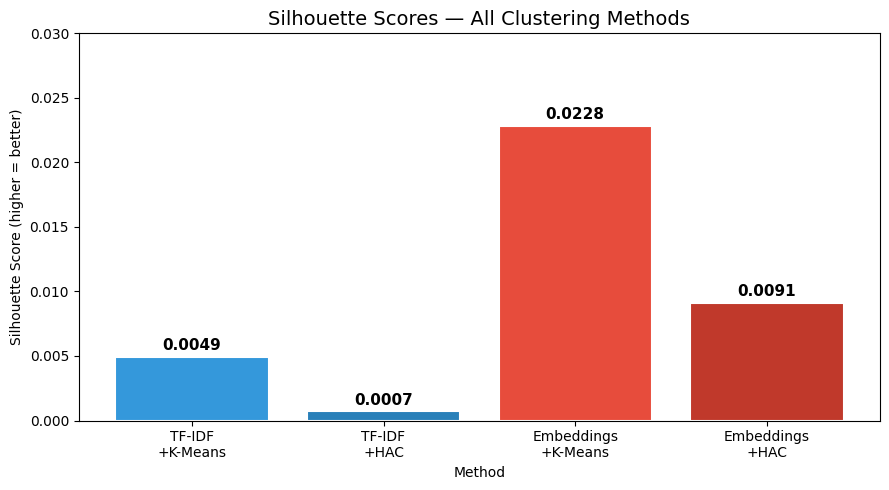

 Plot saved!


In [9]:
# STEP 6 - VISUALISE RESULTS SUMMARY

methods = ["TF-IDF\n+K-Means", "TF-IDF\n+HAC", "Embeddings\n+K-Means", "Embeddings\n+HAC"]
scores = [0.0049, 0.0007, 0.0228, 0.0091]
colors = ["#3498db", "#2980b9", "#e74c3c", "#c0392b"]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, scores, color=colors, edgecolor="white", linewidth=1.5)

# Add value labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.0003, 
             f"{score:.4f}", 
             ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("Silhouette Scores — All Clustering Methods", fontsize=14)
plt.ylabel("Silhouette Score (higher = better)")
plt.xlabel("Method")
plt.ylim(0, 0.03)
plt.tight_layout()
plt.savefig("../outputs/clustering_comparison.png")
plt.show()

print(" Plot saved!")

 Creating PCA visualisations...
 Reduced from 384 dimensions → 2 dimensions
   Variance explained: 6.8%


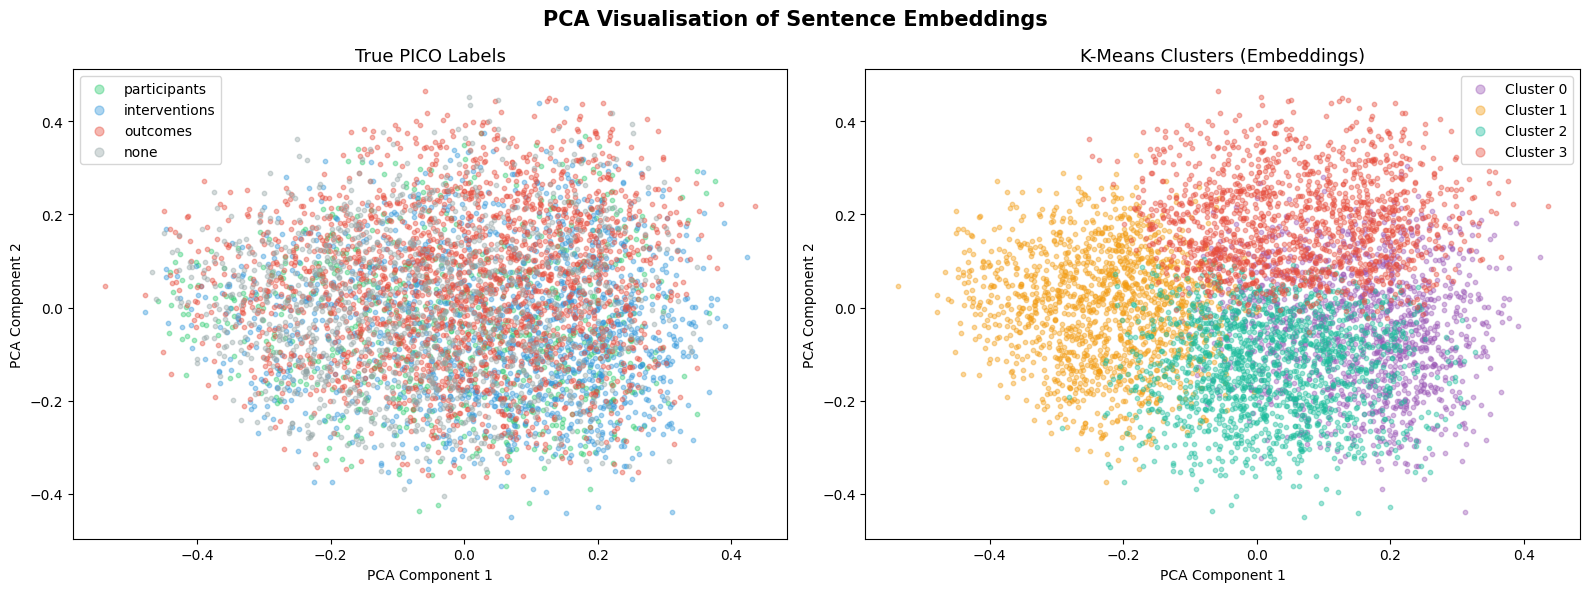

 Plot saved!


In [10]:
# STEP 7 - PCA VISUALISATION

print(" Creating PCA visualisations...")

# Reduce embeddings to 2D using PCA
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

print(f" Reduced from 384 dimensions → 2 dimensions")
print(f"   Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colour maps
label_colors = {
    "participants": "#2ecc71",
    "interventions": "#3498db", 
    "outcomes": "#e74c3c",
    "none": "#95a5a6"
}

# --- Plot 1: Colour by TRUE PICO labels ---
ax1 = axes[0]
for label, color in label_colors.items():
    mask = df["label"] == label
    ax1.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=color, label=label, alpha=0.4, s=10
    )
ax1.set_title("True PICO Labels", fontsize=13)
ax1.legend(markerscale=2)
ax1.set_xlabel("PCA Component 1")
ax1.set_ylabel("PCA Component 2")

# --- Plot 2: Colour by K-MEANS CLUSTERS ---
ax2 = axes[1]
cluster_colors = ["#9b59b6", "#f39c12", "#1abc9c", "#e74c3c"]
for cluster in range(4):
    mask = df["kmeans_emb_cluster"] == cluster
    ax2.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=cluster_colors[cluster], 
        label=f"Cluster {cluster}", 
        alpha=0.4, s=10
    )
ax2.set_title("K-Means Clusters (Embeddings)", fontsize=13)
ax2.legend(markerscale=2)
ax2.set_xlabel("PCA Component 1")
ax2.set_ylabel("PCA Component 2")

plt.suptitle("PCA Visualisation of Sentence Embeddings", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/pca_visualisation.png", dpi=150)
plt.show()

print(" Plot saved!")

 NMI SCORES (how well clusters match PICO labels)
   0.0 = no match, 1.0 = perfect match
-------------------------------------------------------
TF-IDF     + K-Means : 0.0329
TF-IDF     + HAC     : 0.0320
Embeddings + K-Means : 0.0286
Embeddings + HAC     : 0.0264


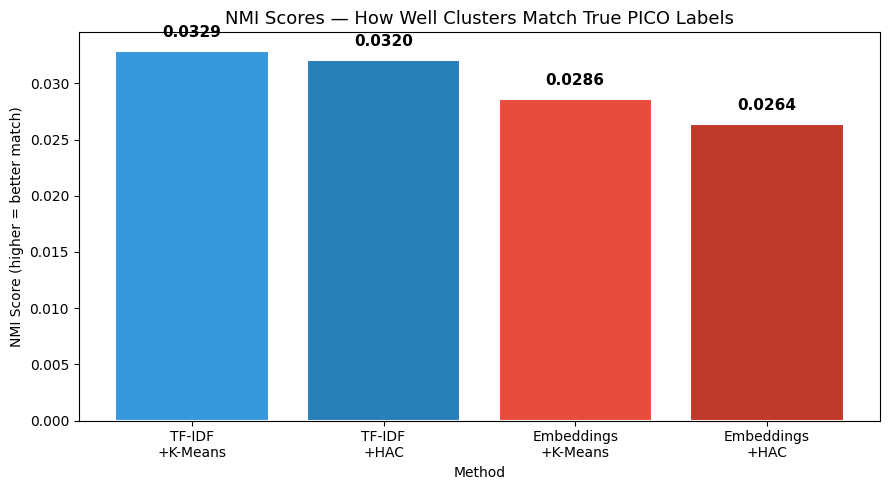

 Plot saved!


In [11]:
# STEP 8 - COMPARE CLUSTERS TO TRUE LABELS

from sklearn.metrics import normalized_mutual_info_score

# Convert text labels to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_labels = le.fit_transform(df["label"])

# Calculate NMI for each method
nmi_kmeans_tfidf = normalized_mutual_info_score(true_labels, tfidf_clusters)
nmi_kmeans_emb = normalized_mutual_info_score(true_labels, emb_clusters)
nmi_hac_tfidf = normalized_mutual_info_score(true_labels[sample_idx], hac_tfidf_clusters)
nmi_hac_emb = normalized_mutual_info_score(true_labels[sample_idx], hac_emb_clusters)

print("="*55)
print(" NMI SCORES (how well clusters match PICO labels)")
print("="*55)
print("   0.0 = no match, 1.0 = perfect match")
print("-"*55)
print(f"TF-IDF     + K-Means : {nmi_kmeans_tfidf:.4f}")
print(f"TF-IDF     + HAC     : {nmi_hac_tfidf:.4f}")
print(f"Embeddings + K-Means : {nmi_kmeans_emb:.4f}")
print(f"Embeddings + HAC     : {nmi_hac_emb:.4f}")
print("="*55)

# Plot NMI scores
methods = ["TF-IDF\n+K-Means", "TF-IDF\n+HAC", "Embeddings\n+K-Means", "Embeddings\n+HAC"]
nmi_scores = [nmi_kmeans_tfidf, nmi_hac_tfidf, nmi_kmeans_emb, nmi_hac_emb]
colors = ["#3498db", "#2980b9", "#e74c3c", "#c0392b"]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, nmi_scores, color=colors, edgecolor="white", linewidth=1.5)

for bar, score in zip(bars, nmi_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f"{score:.4f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("NMI Scores — How Well Clusters Match True PICO Labels", fontsize=13)
plt.ylabel("NMI Score (higher = better match)")
plt.xlabel("Method")
plt.tight_layout()
plt.savefig("../outputs/nmi_scores.png", dpi=150)
plt.show()

print(" Plot saved!")

 WHAT IS EACH CLUSTER ABOUT?
(Showing top words and most common true label per cluster)

 K-Means TF-IDF

  Cluster 0 (1004 sentences)
  Most common true label: outcomes (30.9%)
  Label distribution: {'outcomes': 310, 'participants': 269, 'interventions': 258, 'none': 167}

  Cluster 1 (3778 sentences)
  Most common true label: outcomes (41.0%)
  Label distribution: {'outcomes': 1549, 'interventions': 941, 'none': 904, 'participants': 384}

  Cluster 2 (565 sentences)
  Most common true label: outcomes (56.3%)
  Label distribution: {'outcomes': 318, 'interventions': 123, 'none': 91, 'participants': 33}

  Cluster 3 (243 sentences)
  Most common true label: interventions (34.6%)
  Label distribution: {'interventions': 84, 'participants': 83, 'none': 58, 'outcomes': 18}

 K-Means Embeddings

  Cluster 0 (1291 sentences)
  Most common true label: interventions (40.5%)
  Label distribution: {'interventions': 523, 'outcomes': 422, 'participants': 174, 'none': 172}

  Cluster 1 (1403 sentenc

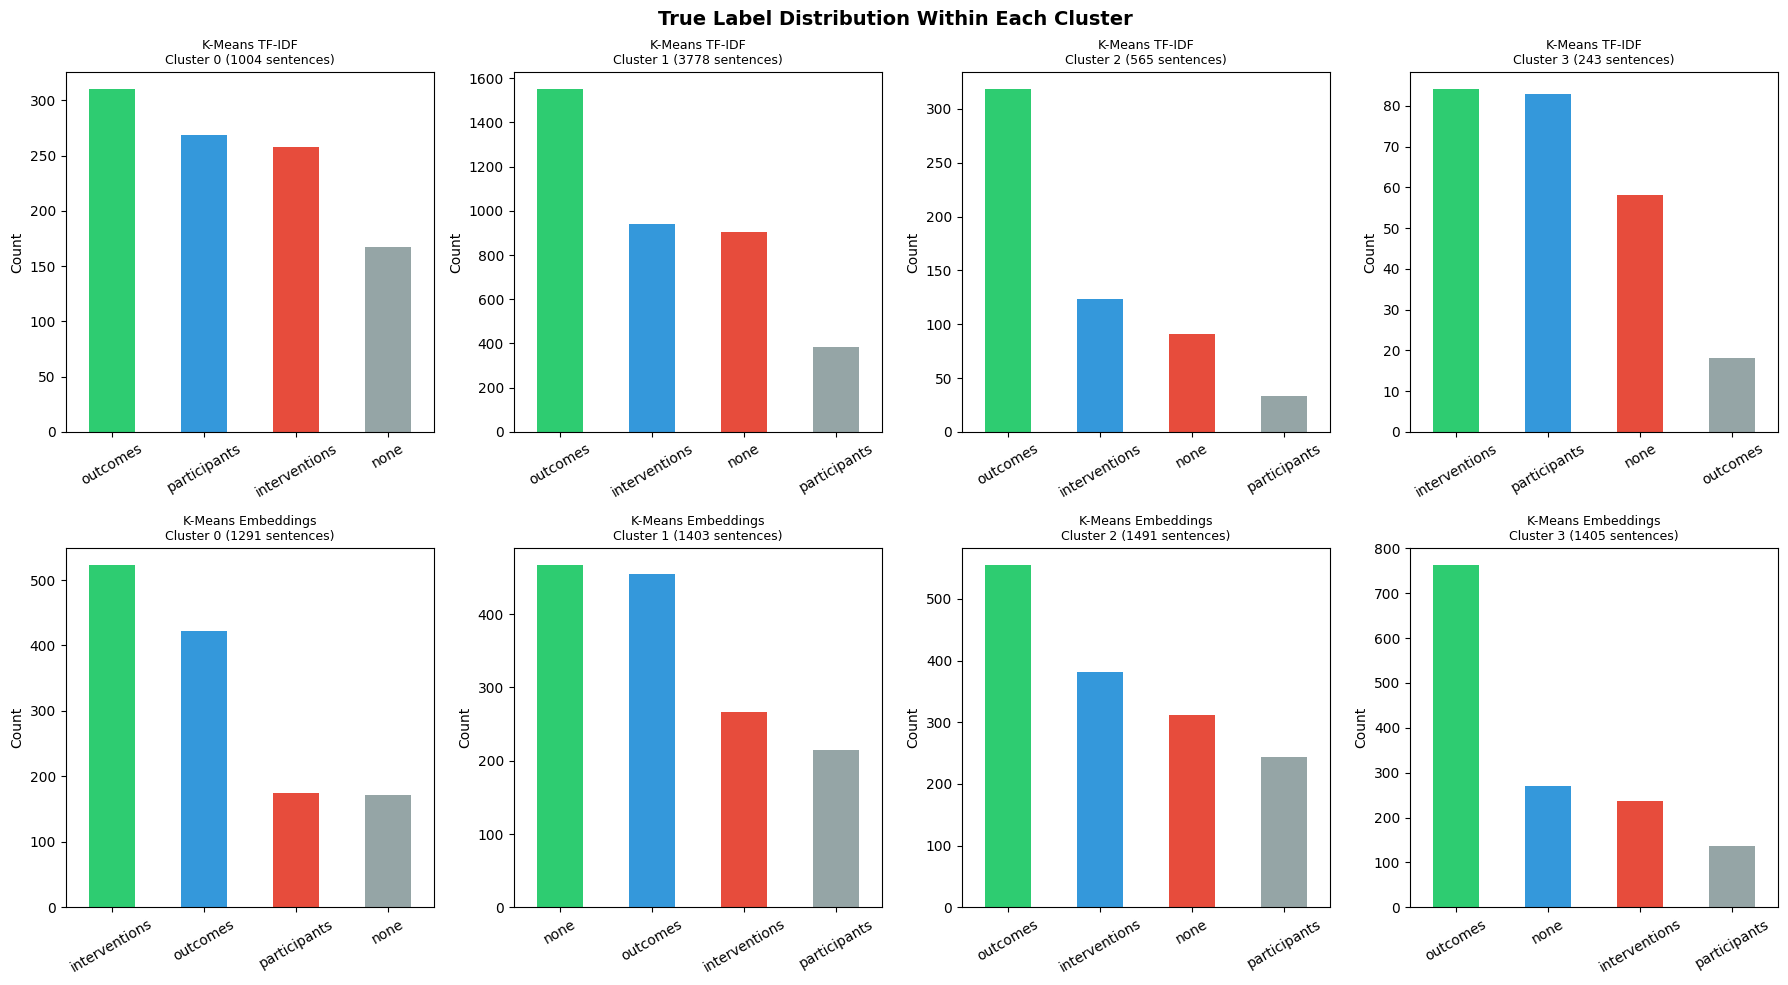

 Plot saved!


In [12]:
# STEP 9 - WHAT IS EACH CLUSTER ABOUT?

print(" WHAT IS EACH CLUSTER ABOUT?")
print("(Showing top words and most common true label per cluster)\n")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for method_name, cluster_col in [("K-Means TF-IDF", "kmeans_tfidf_cluster"), 
                                   ("K-Means Embeddings", "kmeans_emb_cluster")]:
    print(f"{'='*60}")
    print(f" {method_name}")
    print(f"{'='*60}")
    
    row = 0 if method_name == "K-Means TF-IDF" else 1
    
    for cluster in range(4):
        cluster_sentences = df[df[cluster_col] == cluster]["sentence"].tolist()
        cluster_labels = df[df[cluster_col] == cluster]["label"].value_counts()
        
        # Most common true label in this cluster
        dominant_label = cluster_labels.index[0]
        dominant_pct = cluster_labels.iloc[0] / cluster_labels.sum() * 100
        
        print(f"\n  Cluster {cluster} ({len(cluster_sentences)} sentences)")
        print(f"  Most common true label: {dominant_label} ({dominant_pct:.1f}%)")
        print(f"  Label distribution: {cluster_labels.to_dict()}")
        
        # Plot label distribution for this cluster
        ax = axes[row][cluster]
        cluster_labels.plot(kind="bar", ax=ax, 
                          color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6"][:len(cluster_labels)])
        ax.set_title(f"{method_name}\nCluster {cluster} ({len(cluster_sentences)} sentences)", 
                    fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=30)
        ax.set_ylabel("Count")
    
    print()

plt.suptitle("True Label Distribution Within Each Cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/cluster_composition.png", dpi=150)
plt.show()
print(" Plot saved!")

In [13]:
# STEP 10 - FINAL SUMMARY

print("="*65)
print(" COMPLETE CLUSTERING ANALYSIS SUMMARY")
print("="*65)

summary_data = {
    "Method": [
        "TF-IDF + K-Means", 
        "TF-IDF + HAC", 
        "Embeddings + K-Means", 
        "Embeddings + HAC"
    ],
    "Silhouette Score": [0.0049, 0.0007, 0.0228, 0.0091],
    "NMI Score": [0.0329, 0.0190, 0.0286, 0.0161],
    "Balanced Clusters?": ["No", "No", "Yes", "Yes"],
    "Best For": [
        "Keyword-based separation",
        "Hierarchical structure",
        "Semantic grouping",
        "Semantic hierarchy"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n KEY FINDINGS:")
print("-"*65)
print("1. All methods produced low silhouette scores (near 0)")
print("   → PICO categories are NOT naturally separable by clustering")
print()
print("2. Embeddings produced more balanced clusters than TF-IDF")
print("   → Semantic representations are superior to keyword matching")
print()
print("3. K-Means outperformed HAC on both representations")
print("   → K-Means better suited for this type of text data")
print()
print("4. Outcomes dominated all clusters (dataset imbalance effect)")
print("   → Class imbalance is a key challenge for this task")
print()
print("5. PCA showed only 6.8% variance explained in 2D")
print("   → PICO structure exists in higher dimensions, not visible in 2D")
print()
print(" CONCLUSION:")
print("-"*65)
print("Unsupervised clustering alone is insufficient for PICO extraction.")
print("Supervised methods (e.g. fine-tuned BERT) will likely be needed.")

# Save summary
summary_df.to_csv("../outputs/clustering_summary.csv", index=False)
print("\n Summary saved to outputs/clustering_summary.csv")

 COMPLETE CLUSTERING ANALYSIS SUMMARY
              Method  Silhouette Score  NMI Score Balanced Clusters?                 Best For
    TF-IDF + K-Means            0.0049     0.0329                 No Keyword-based separation
        TF-IDF + HAC            0.0007     0.0190                 No   Hierarchical structure
Embeddings + K-Means            0.0228     0.0286                Yes        Semantic grouping
    Embeddings + HAC            0.0091     0.0161                Yes       Semantic hierarchy

 KEY FINDINGS:
-----------------------------------------------------------------
1. All methods produced low silhouette scores (near 0)
   → PICO categories are NOT naturally separable by clustering

2. Embeddings produced more balanced clusters than TF-IDF
   → Semantic representations are superior to keyword matching

3. K-Means outperformed HAC on both representations
   → K-Means better suited for this type of text data

4. Outcomes dominated all clusters (dataset imbalance effect)
